# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [3]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

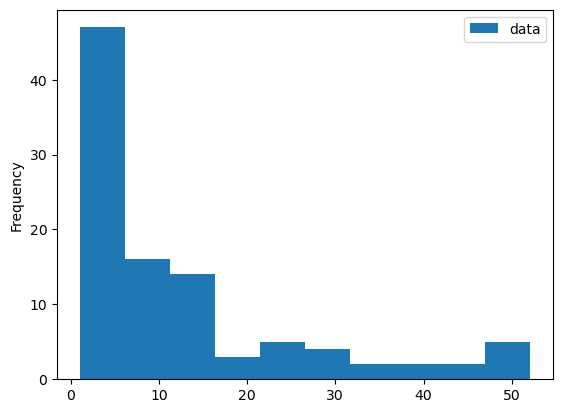

In [4]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

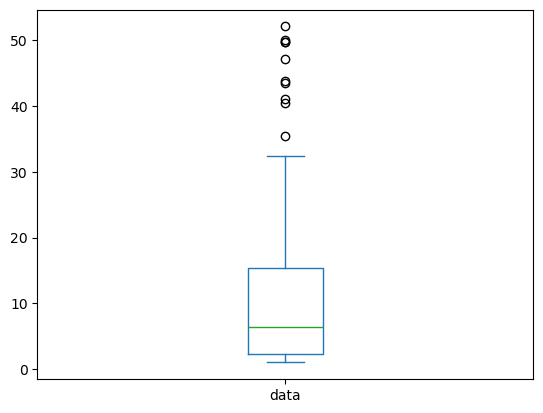

In [5]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

Diabetes Dataset

In [6]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

df.shape

(253680, 22)

In [7]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [9]:
list(df.columns)

['Diabetes_binary',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [10]:
df['Diabetes_binary'].value_counts()

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

<Axes: xlabel='Diabetes_binary'>

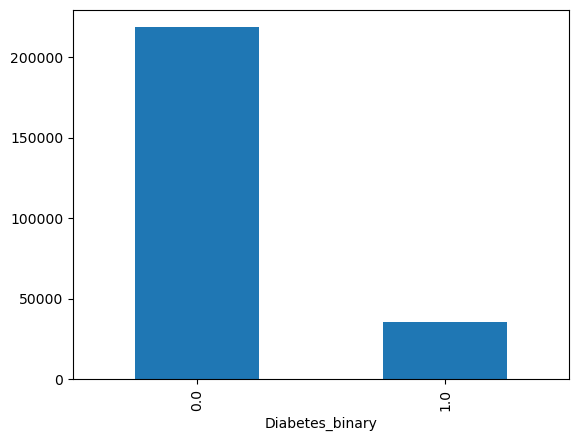

In [11]:
df['Diabetes_binary'].value_counts().plot.bar()

In [12]:
df['BMI'].describe()

count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64

<Axes: ylabel='Frequency'>

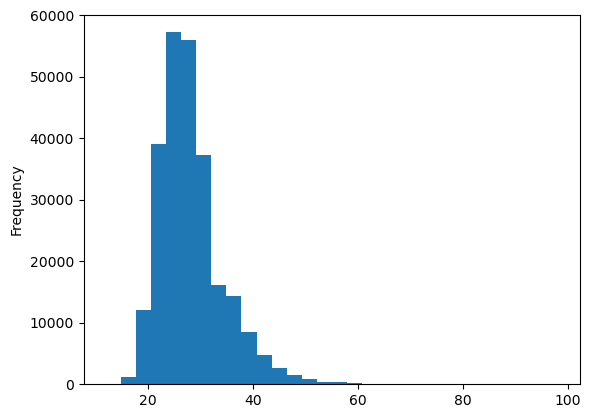

In [13]:
df['BMI'].plot.hist(bins=30)

<Axes: >

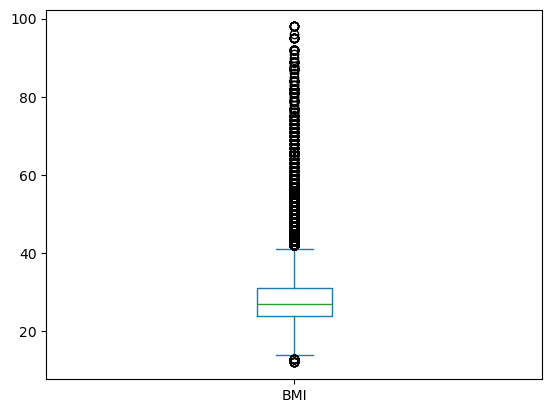

In [14]:
df['BMI'].plot.box()

<Axes: xlabel='Age'>

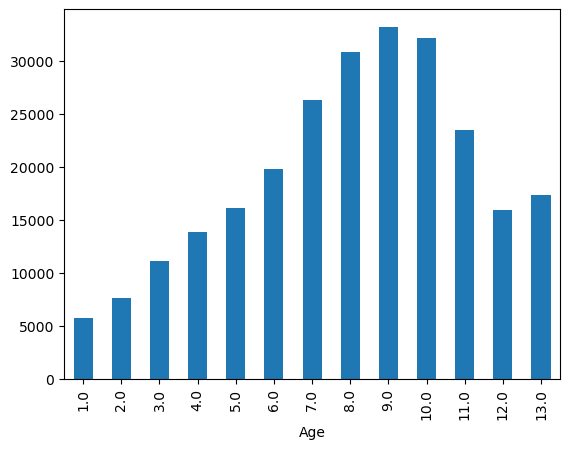

In [15]:
df['Age'].value_counts().sort_index().plot.bar()

<Axes: xlabel='Income'>

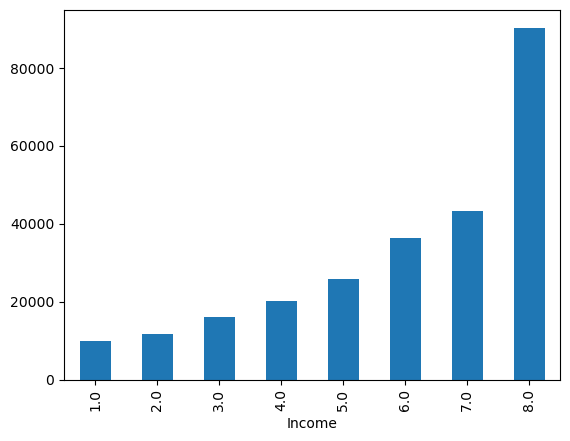

In [16]:
df['Income'].value_counts().sort_index().plot.bar()

<Axes: xlabel='Education'>

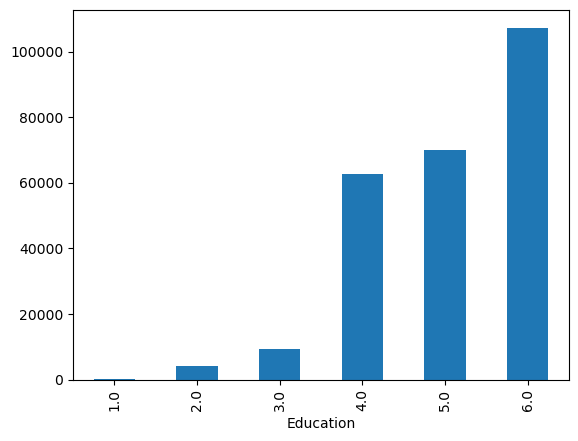

In [17]:
df['Education'].value_counts().sort_index().plot.bar()

In [18]:
df['Age'] = df['Age'].astype('category')
df['Income'] = df['Income'].astype('category')
df['Education'] = df['Education'].astype('category')

In [19]:
# 1) See all columns (you already did this, but do it cleanly here)
print(df.shape)
print(df.columns.tolist())

(253680, 22)
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [20]:
# 2) Look for anything geographic
geo_keywords = ["state", "State", "STATE", "county", "County", "fips", "FIPS", "zip", "ZIP", "tract", "Tract", "region"]
[c for c in df.columns if any(k.lower() in c.lower() for k in geo_keywords)]

[]

KFF Diabetes Dataset

In [21]:
kff = pd.read_csv('raw_data.csv', skiprows=2)

print(kff.shape)

(65, 6)


In [22]:
print(kff.columns)

Index(['Location', 'Ages 18-44', 'Ages 45-64', 'Ages 65-74', 'Ages 75+',
       'Total (Age-Adjusted)'],
      dtype='object')


In [23]:
print(kff.head())

        Location Ages 18-44 Ages 45-64 Ages 65-74 Ages 75+  \
0  United States      0.022      0.128      0.221    0.212   
1        Alabama      0.041      0.178      0.283    0.252   
2         Alaska        NSD      0.116      0.198    0.207   
3        Arizona      0.027      0.139      0.200    0.215   
4       Arkansas      0.029      0.191      0.239    0.228   

  Total (Age-Adjusted)  
0                0.087  
1                0.120  
2                0.078  
3                0.091  
4                0.112  


In [24]:
# Remove United States row (optional but recommended)
kff = kff[kff["Location"] != "United States"]

# Convert total prevalence to numeric
kff["Total (Age-Adjusted)"] = pd.to_numeric(kff["Total (Age-Adjusted)"], errors="coerce")

In [25]:
kff = kff.rename(columns={
    "Location": "State",
    "Total (Age-Adjusted)": "DiabetesRate"
})

Census Dataset

In [26]:
census = pd.read_csv("acs2017_county_data.csv")   # <-- change filename to yours
print(census.shape)
print(census.columns.tolist()[:50])  # first 50 column names

(3220, 37)
['CountyId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment']


In [27]:
[c for c in census.columns if "state" in c.lower()]

['State']

In [28]:
print(census.columns[:20])

Index(['CountyId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic',
       'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen',
       'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty',
       'ChildPoverty', 'Professional'],
      dtype='object')


In [29]:
state_census = census.groupby("State").agg({
    "IncomePerCap": "mean",
    "Poverty": "mean",
    "TotalPop": "sum"
}).reset_index()

print(state_census.head())

        State  IncomePerCap    Poverty  TotalPop
0     Alabama  22180.492537  20.949254   4850771
1      Alaska  31670.551724  13.555172    738565
2     Arizona  22712.200000  20.193333   6809946
3    Arkansas  21449.306667  20.421333   2977944
4  California  30416.482759  15.737931  38982847


Merged

In [30]:
merged = pd.merge(kff, state_census, on="State", how="inner")

print(merged.head())

        State Ages 18-44 Ages 45-64 Ages 65-74 Ages 75+  DiabetesRate  \
0     Alabama      0.041      0.178      0.283    0.252         0.120   
1      Alaska        NSD      0.116      0.198    0.207         0.078   
2     Arizona      0.027      0.139      0.200    0.215         0.091   
3    Arkansas      0.029      0.191      0.239    0.228         0.112   
4  California      0.028      0.137      0.240    0.230         0.096   

   IncomePerCap    Poverty  TotalPop  
0  22180.492537  20.949254   4850771  
1  31670.551724  13.555172    738565  
2  22712.200000  20.193333   6809946  
3  21449.306667  20.421333   2977944  
4  30416.482759  15.737931  38982847  


In [31]:
print(merged.shape)
print(merged.isna().sum())

(52, 9)
State           0
Ages 18-44      0
Ages 45-64      0
Ages 65-74      0
Ages 75+        0
DiabetesRate    0
IncomePerCap    0
Poverty         0
TotalPop        0
dtype: int64


In [32]:
print(merged[["DiabetesRate", "IncomePerCap", "Poverty"]].corr())

              DiabetesRate  IncomePerCap   Poverty
DiabetesRate      1.000000     -0.594000  0.781213
IncomePerCap     -0.594000      1.000000 -0.678632
Poverty           0.781213     -0.678632  1.000000


In [33]:
plt.scatter(merged["Poverty"], merged["DiabetesRate"])
plt.xlabel("Poverty (%)")
plt.ylabel("Diabetes Rate")
plt.title("Poverty vs Diabetes Rate")
plt.show()

NameError: name 'plt' is not defined

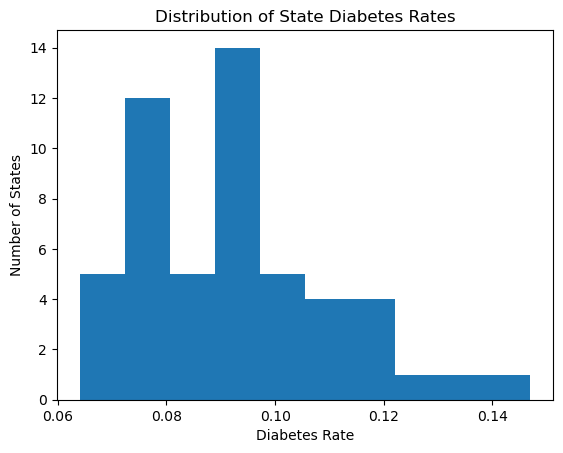

In [ ]:
plt.hist(merged["DiabetesRate"], bins=10)
plt.xlabel("Diabetes Rate")
plt.ylabel("Number of States")
plt.title("Distribution of State Diabetes Rates")
plt.show()

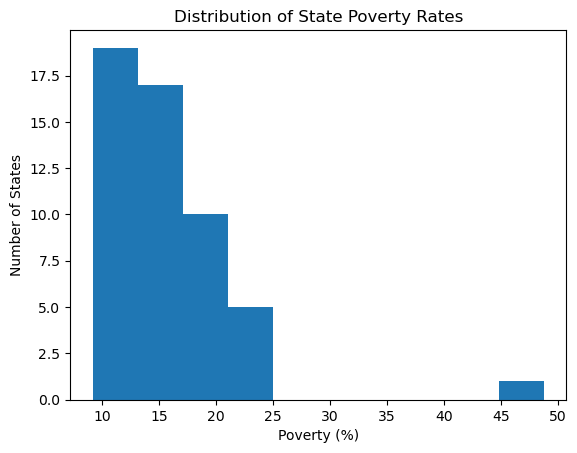

In [ ]:
plt.hist(merged["Poverty"], bins=10)
plt.xlabel("Poverty (%)")
plt.ylabel("Number of States")
plt.title("Distribution of State Poverty Rates")
plt.show()

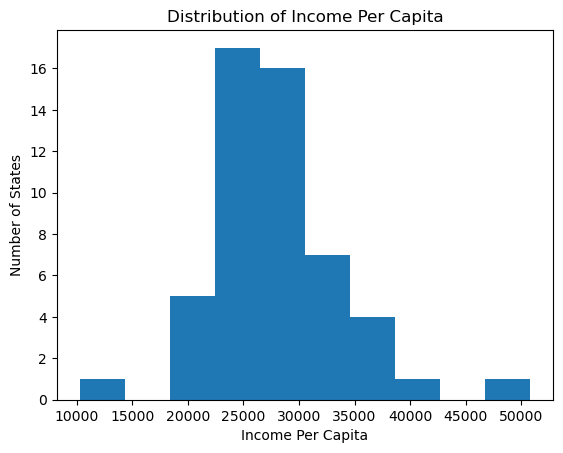

In [ ]:
plt.hist(merged["IncomePerCap"], bins=10)
plt.xlabel("Income Per Capita")
plt.ylabel("Number of States")
plt.title("Distribution of Income Per Capita")
plt.show()

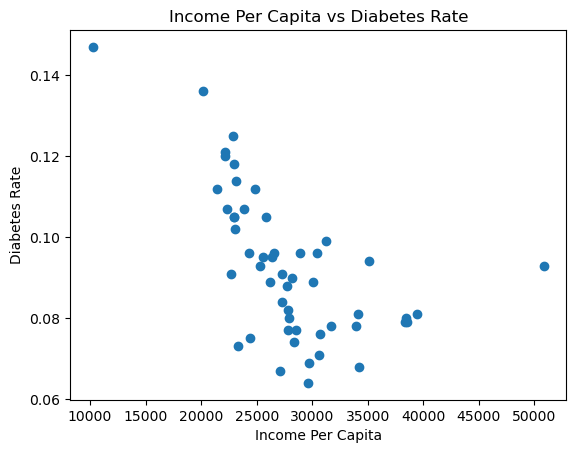

In [ ]:
plt.scatter(merged["IncomePerCap"], merged["DiabetesRate"])
plt.xlabel("Income Per Capita")
plt.ylabel("Diabetes Rate")
plt.title("Income Per Capita vs Diabetes Rate")
plt.show()

In [ ]:
merged[["DiabetesRate", "Poverty", "IncomePerCap"]].describe()

,DiabetesRate,Poverty,IncomePerCap
count,52.000000,52.000000,52.000000
mean,0.092692,15.686635,27877.116704
std,0.018205,6.034066,6258.315444
min,0.064000,9.200000,10244.961538
25%,0.078750,11.873333,23291.576316
50%,0.091000,14.437812,27248.410873
75%,0.105000,17.630500,30455.594212
max,0.147000,48.729487,50832.000000


Conclusions:

The original diabetes dataset from the CDC on Kaggle did not contain state level information, so I replaced it with a CDC dataset from KFF that does.

The merged dataset includes 52 state-level observations with no missing values in the selected variables, making it suitable for exploratory analysis. Diabetes prevalence across states ranges from approximately 6.4% to 14.7%, with a mean of 9.3%. The distribution is slightly right-skewed, with most states clustering between 7% and 11%.

State poverty rates show greater variability, ranging from 9.2% to 48.7%, and display a clear right-skewed distribution with one extreme outlier. Income per capita ranges from approximately $10,245 to $50,832, with most states concentrated between $22,000 and $32,000.

The scatterplots and correlation analysis reveal a strong positive relationship between poverty and diabetes prevalence (r ≈ 0.78), indicating that states with higher poverty rates tend to have higher diabetes rates. Conversely, income per capita shows a moderate-to-strong negative relationship with diabetes prevalence (r ≈ -0.59), suggesting that higher-income states tend to have lower diabetes rates.

Overall, the exploratory analysis supports the hypothesis that economic conditions are associated with variation in state-level diabetes prevalence. These findings suggest that socioeconomic factors may play an important role in health outcomes across states.

In [34]:
merged.sort_values("Poverty", ascending=False)[["State", "Poverty"]].head(10)

,State,Poverty
51,Puerto Rico,48.729487
24,Mississippi,24.941463
18,Louisiana,21.900000
31,New Mexico,21.742424
17,Kentucky,21.304167
10,Georgia,21.192453
0,Alabama,20.949254
3,Arkansas,20.421333
2,Arizona,20.193333
40,South Carolina,20.063043


In [36]:
merged["Poverty"].max()

48.72948717948718

In [37]:
merged = merged[merged["State"] != "Puerto Rico"]

In [38]:
merged["Poverty"].max()

24.941463414634146

In [39]:
merged.shape

(51, 9)

In [41]:
import matplotlib.pyplot as plt

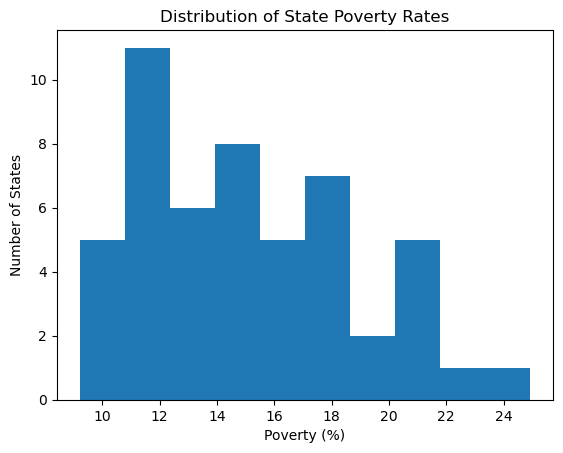

In [42]:
plt.hist(merged["Poverty"], bins=10)
plt.xlabel("Poverty (%)")
plt.ylabel("Number of States")
plt.title("Distribution of State Poverty Rates")
plt.show()

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
import matplotlib.pyplot as plt

/var/folders/hb/x2mhw6jn7x35b5xw13m920y00000gn/T/ipykernel_60785/2512823197.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age")


TypeError: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one


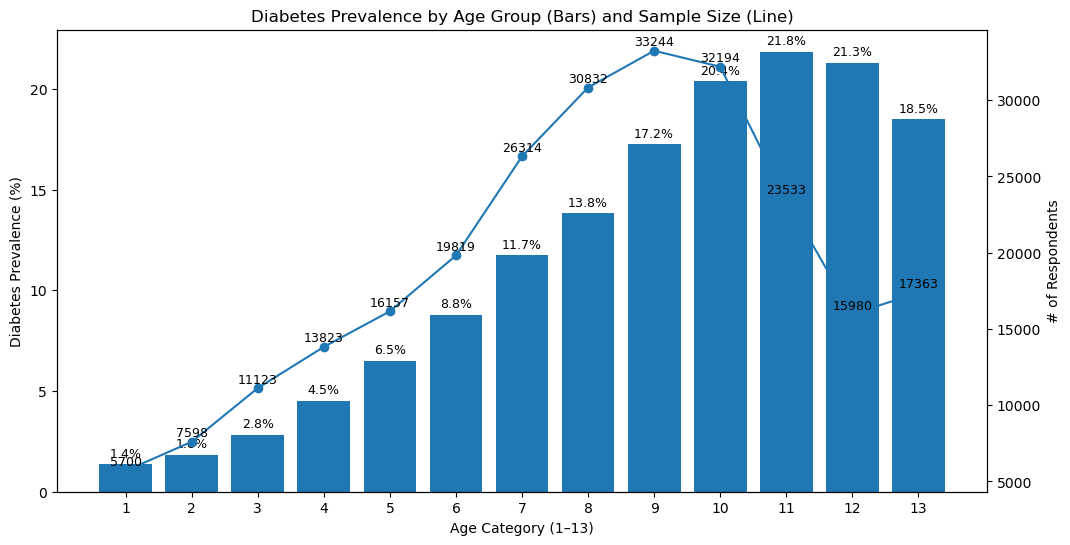

In [ ]:
# 1) group by Age and compute:
#    - diabetes_rate = mean of Diabetes_binary (since it's 0/1)
#    - n = number of rows in each age group
summary_age = (
    df.groupby("Age")
      .agg(diabetes_rate=("Diabetes_binary", "mean"),
           n=("Diabetes_binary", "size"))
      .reset_index()
      .sort_values("Age")
)

# convert rate to percent
summary_age["diabetes_pct"] = summary_age["diabetes_rate"] * 100

summary_age.head()

# --- figure setup ---
fig, ax1 = plt.subplots(figsize=(12, 6))

x = summary_age["Age"]
bars = ax1.bar(x, summary_age["diabetes_pct"])

# Left axis = diabetes %
ax1.set_ylabel("Diabetes Prevalence (%)")
ax1.set_xlabel("Age Category (1–13)")
ax1.set_title("Diabetes Prevalence by Age Group (Bars) and Sample Size (Line)")

# Make x ticks show all categories
ax1.set_xticks(x)
ax1.set_xticklabels([str(int(i)) for i in x])

# Direct labels on bars (like the book figure)
for bar, pct in zip(bars, summary_age["diabetes_pct"]):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Right axis = sample size line
ax2 = ax1.twinx()
ax2.plot(x, summary_age["n"], marker="o")
ax2.set_ylabel("# of Respondents")

# Direct labels on line points
for xi, ni in zip(x, summary_age["n"]):
    ax2.text(xi, ni + (summary_age["n"].max() * 0.01), f"{int(ni)}", ha="center", fontsize=9)

# Remove legends (book style relies on direct labeling)
# Add small direct text annotations instead
ax1.text(x.min(), summary_age["diabetes_pct"].max() * 0.95, "Diabetes Prevalence (%)", fontsize=10)
ax2.text(x.min(), summary_age["n"].max() * 0.95, "# of Respondents", fontsize=10)

plt.tight_layout()
plt.show()

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.grid(axis="y", alpha=0.2)